# Proyecto: Rusty Bargain, predicción del valor de mercado de coches usados

El servicio de venta de autos usados Rusty Bargain está desarrollando una aplicación para atraer nuevos clientes. Gracias a esa app, puedes averiguar rápidamente el valor de mercado de tu coche. Tienes acceso al historial: especificaciones técnicas, versiones de equipamiento y precios. Tienes que crear un modelo que determine el valor de mercado.
A Rusty Bargain le interesa:
- la calidad de la predicción;
- la velocidad de la predicción;
- el tiempo requerido para el entrenamiento

## Objetivo general

Construir un modelo que prediga el precio de mercado de un coche usado a partir de sus características. A Rusty Bargain no solo le importa que la predicción sea buena, también cuánto tarda el modelo en entrenar y en predecir, así que se debe comparar los modelos en esos tres aspectos. La calidad se mide con la métrica 'RECM'.

## Descripción de los datos

El archivo 'car_data.csv' tiene un anuncio de coche por fila.

Características:
- 'DateCrawled': fecha en la que se descargó el perfil de la base de datos
- 'VehicleType': tipo de carrocería del vehículo
- 'RegistrationYear': año de matriculación del vehículo
- 'Gearbox': tipo de caja de cambios
- 'Power': potencia (CV)
- 'Model': modelo del vehículo
- 'Mileage': kilometraje (km)
- 'RegistrationMonth': mes de matriculación del vehículo
- 'FuelType': tipo de combustible
- 'Brand': marca del vehículo
- 'NotRepaired': vehículo con o sin reparación
- 'DateCreated': fecha de creación del perfil
- 'NumberOfPictures': número de fotos del vehículo
- 'PostalCode': código postal del propietario del perfil
- 'LastSeen': fecha de la última vez que el usuario estuvo activo

Objetivo:
- 'Price': precio en euros

## 1. Preparación de datos

### 1.1 Carga y primer vistazo

**Objetivo:** cargar los datos y revisar tipos, valores ausentes, duplicados y rangos de las columnas numéricas para saber qué hay que limpiar.

In [1]:
# Importamos librerías
import time  # Nos Sirve para medir los tiempos de entrenamiento y de predicción
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Cargamos los datos. usamos try catch para probar en local y que no se rompa en la plataforma
try:
    datos = pd.read_csv('car_data.csv')
except FileNotFoundError:
    datos = pd.read_csv('/datasets/car_data.csv')

datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

In [2]:
# Vemos la
display(datos.head())
display(datos.describe())

# Contamos los valores ausentes y las filas duplicadas
print(datos.isna().sum())
print('Filas duplicadas:', datos.duplicated().sum())

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17


,Price,RegistrationYear,Power,Mileage,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64
Filas duplicadas: 262


**Conclusión:** el dataset tiene 354369 anuncios y 16 columnas. Hay 262 filas duplicadas y ausentes en cinco columnas de texto; la que más tiene es `NotRepaired`, con 71154. En las columnas numéricas aparecen valores imposibles: precios de 0 euros, años de matriculación entre 1000 y 9999 y potencias que van de 0 a 20000 CV. Además, `NumberOfPictures` vale 0 en todas las filas.

### 1.2 Duplicados y columnas que no describen al coche

**Objetivo:** quitar las filas repetidas y las columnas que no ayudan a explicar el precio. Las fechas del anuncio, el código postal y el número de fotos son datos del anuncio, no del vehículo. Antes de quitarlas revisamos la fecha de descarga, porque dice cuál es el año de matriculación más reciente posiblEe

In [3]:
# Eliminarmos las filas duplicadas
datos = datos.drop_duplicates().reset_index(drop=True)

# revisamos las columnas que pensamos quitar antes de quiarlas
fechas_descarga = pd.to_datetime(datos['DateCrawled'], format='%d/%m/%Y %H:%M')
print('Fecha de descarga más antigua:', fechas_descarga.min())
print('Fecha de descarga más reciente:', fechas_descarga.max())
print('Valores distintos en NumberOfPictures:', datos['NumberOfPictures'].unique())
print('Filas con RegistrationMonth igual a 0:', (datos['RegistrationMonth'] == 0).sum())

# ahora vamos a quitar las columnas que no describen al vehpiculo
columnas_sin_uso = ['DateCrawled', 'DateCreated', 'LastSeen', 'NumberOfPictures', 'PostalCode', 'RegistrationMonth']
datos = datos.drop(columnas_sin_uso, axis=1)
print('Tamaño después de limpiar:', datos.shape)

Fecha de descarga más antigua: 2016-03-05 14:06:00
Fecha de descarga más reciente: 2016-04-07 14:36:00
Valores distintos en NumberOfPictures: [0]
Filas con RegistrationMonth igual a 0: 37347
Tamaño después de limpiar: (354107, 10)


**Conclusión:** Se eliminan las 262 filas duplicadas. Los anuncios se descargaron entre marzo y abril de 2016, así que ningún vehículo puede estar matriculado después de 2016. `NumberOfPictures` solo tiene ceros y no aporta nada. `RegistrationMonth` tiene 37347 filas con mes 0, que no existe, y el año ya dice casi lo mismo, así que también se remueve. Me quedé con 354107 filas y 10 columnas: el precio y 9 características del coche.

### 1.3 Valores imposibles

**Objetivo:** encontrar precios, años y potencias que no pueden ser posibles. Primero medimos el impacto en  filas para cada filtro

In [4]:
# Medimos cuántas filas tienen valores imposibles en cada columna
print('Precio menor a 100 euros:', (datos['Price'] < 100).sum())
print('Precio igual a 0:', (datos['Price'] == 0).sum())
print('Año de matriculación antes de 1950:', (datos['RegistrationYear'] < 1950).sum())
print('Año de matriculación después de 2016:', (datos['RegistrationYear'] > 2016).sum())
print('Potencia menor a 30 CV:', (datos['Power'] < 30).sum())
print('Potencia igual a 0:', (datos['Power'] == 0).sum())
print('Potencia mayor a 500 CV:', (datos['Power'] > 500).sum())

Precio menor a 100 euros: 13311
Precio igual a 0: 10770
Año de matriculación antes de 1950: 246
Año de matriculación después de 2016: 14529
Potencia menor a 30 CV: 41126
Potencia igual a 0: 40218
Potencia mayor a 500 CV: 459


In [5]:
# ahora vamos a quitar los anuncios con precio o año imposibles
filas_antes = len(datos)
datos = datos[datos['Price'] >= 100]
datos = datos[(datos['RegistrationYear'] >= 1950) & (datos['RegistrationYear'] <= 2016)]
datos = datos.reset_index(drop=True)
filas_eliminadas = filas_antes - len(datos)
print('Filas eliminadas:', filas_eliminadas, 'de', filas_antes, '=', round(filas_eliminadas / filas_antes * 100, 1), '%')

# la potencia fuera de rango la marcamos como ausente y la rellenamos en el siguiente paso
datos['Power'] = datos['Power'].astype('float')
datos.loc[(datos['Power'] < 30) | (datos['Power'] > 500), 'Power'] = np.nan
print('Potencias marcadas como ausentes:', datos['Power'].isna().sum())

# comprobamos que los filtros funcionaron
print('Precio mínimo:', datos['Price'].min())
print('Año mínimo:', datos['RegistrationYear'].min(), '| año máximo:', datos['RegistrationYear'].max())

Filas eliminadas: 27142 de 354107 = 7.7 %
Potencias marcadas como ausentes: 32743
Precio mínimo: 100
Año mínimo: 1950 | año máximo: 2016


**Conclusión:** 13311 anuncios tienen un precio menor a 100 euros, y 10770 de ellos están en 0. No son precios reales de venta y le enseñarían al modelo que un coche puede no valer nada, así que los quité. También quité 246 vehículos matriculados antes de 1950 y 14529 después de 2016, porque esos años son errores de captura. En total perdí 27142 filas, el 7.7 %.

Con la potencia no hacemos lo mismo: 41126 vehículos tienen menos de 30 CV, casi todos con 0, y 459 tienen más de 500 CV. Borrarlos costaría más del 11 % de los datos, así que los marcamos como ausentes para rellenarlos. Después de los otros filtros quedaron 32743 potencias por rellenar. Los filtros funcionaron: el precio mínimo ahora es 100 y los años van de 1950 a 2016.

### 1.4 Valores ausentes

**Objetivo:** decidir cómo tratar los ausentes de las columnas de texto y de la potencia, midiendo antes cuántas filas se perderían si simplemente las borrara.

In [6]:
# Medimos cuántas filas perderíamos si borráramos las que tienen algún ausente
columnas_texto = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'NotRepaired']
filas_con_ausentes = datos[columnas_texto].isna().any(axis=1).sum()
print('Filas con algún ausente en columnas de texto:', filas_con_ausentes, '=', round(filas_con_ausentes / len(datos) * 100, 1), '%')

# en las columnas de texto el ausente pasa a ser una categoría más
datos[columnas_texto] = datos[columnas_texto].fillna('unknown')

# la potencia la rellenamos con la mediana de los coches del mismo modelo
datos['Power'] = datos['Power'].fillna(datos.groupby('Model')['Power'].transform('median'))
print('Potencias sin rellenar después de usar el modelo:', datos['Power'].isna().sum())
# si un modelo no tiene ninguna potencia válida usamos la mediana general
datos['Power'] = datos['Power'].fillna(datos['Power'].median())

print(datos.isna().sum())

Filas con algún ausente en columnas de texto: 85446 = 26.1 %
Potencias sin rellenar después de usar el modelo: 1
Price               0
VehicleType         0
RegistrationYear    0
Gearbox             0
Power               0
Model               0
Mileage             0
FuelType            0
Brand               0
NotRepaired         0
dtype: int64


**Conclusión:** 85446 filas, el 26.1 %, tienen al menos un ausente en las columnas de texto. Borrarlas sería perder una cuarta parte de los datos, así que los ausentes pasaron a ser la categoría `unknown`. En `NotRepaired` esto tiene sentido: que la celda esté vacía también nos dice algo

Para la potencia usé la mediana de los vehículos del mismo modelo, porque dos vehículos del mismo modelo suelen tener una potencia parecida. Para esto solo uso la columna de potencia, no el precio. Solo quedó 1 fila sin rellenar, que tomó la mediana general, y ya no quedan ausentes.

### 1.5 División de los datos y codificación

**Objetivo:** separar los datos en entrenamiento, validación y prueba, y preparar las categorías como las necesita cada modelo.

In [7]:
# Separamos las características del objetivo
features = datos.drop('Price', axis=1)
target = datos['Price']
columnas_categoricas = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']

# dividimos en entrenamiento (60 %), validación (20 %) y prueba (20 %)
features_train, features_rest, target_train, target_rest = train_test_split(
    features, target, test_size=0.4, random_state=12345)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_rest, target_rest, test_size=0.5, random_state=12345)

print('Entrenamiento:', features_train.shape)
print('Validación:', features_valid.shape)
print('Prueba:', features_test.shape)

Entrenamiento: (196179, 9)
Validación: (65393, 9)
Prueba: (65393, 9)


In [8]:
# regresión lineal: One-Hot Encoding, quitando la primera columna de cada categoría
features_ohe = pd.get_dummies(features, columns=columnas_categoricas, drop_first=True)
ohe_train = features_ohe.loc[features_train.index]
ohe_valid = features_ohe.loc[features_valid.index]
print('Columnas después de OHE:', features_ohe.shape[1])

# árbol de decisión y bosque aleatorio: cada categoría pasa a ser un número
encoder = OrdinalEncoder()
features_ord = features.copy()
features_ord[columnas_categoricas] = encoder.fit_transform(features[columnas_categoricas])
ord_train = features_ord.loc[features_train.index]
ord_valid = features_ord.loc[features_valid.index]

# LightGBM trabaja directamente con columnas de tipo category
features_lgbm = features.copy()
for columna in columnas_categoricas:
    features_lgbm[columna] = features_lgbm[columna].astype('category')
lgbm_train = features_lgbm.loc[features_train.index]
lgbm_valid = features_lgbm.loc[features_valid.index]
lgbm_test = features_lgbm.loc[features_test.index]

# CatBoost usa las columnas de texto tal cual, solo hay que decirle cuáles son categóricas
print('Columnas para árboles, LightGBM y CatBoost:', features.shape[1])

Columnas después de OHE: 311
Columnas para árboles, LightGBM y CatBoost: 9


**Conclusión:** quedaron 196179 filas para entrenar y 65393 para validación y para prueba. Con One-Hot Encoding la regresión lineal trabaja con 311 columnas, mientras que los árboles, LightGBM y CatBoost trabajan con las 9 características originales.

## 2. Entrenamiento del modelo

### 2.1 Línea base y regresión lineal

**Objetivo:** tener dos referencias antes de probar modelos más complejos. La línea base predice siempre el precio medio, y cualquier modelo útil tiene que mejorarla. La regresión lineal es la prueba de cordura: si la potenciación del gradiente sale peor que ella, algo está mal.

Para no repetir código escribo una función que entrena el modelo, mide el tiempo de entrenamiento y de predicción y guarda la RECM en validación. En cada celda de entrenamiento uso además `%%time`, el comando de Jupyter que mide cuánto tarda la celda completa.

In [9]:
# Definimos la función de la RECM
def recm(target, predicciones):
    return mean_squared_error(target, predicciones) ** 0.5

# aquí guardaremos los resultados de cada modelo para compararlos al final
resultados = []

# esta función entrena un modelo, mide los tiempos y guarda la RECM en validación
def evaluar_modelo(nombre, hiperparametros, modelo, features_tr, features_va, cat_features=None):
    inicio = time.time()
    if cat_features is None:
        modelo.fit(features_tr, target_train)
    else:
        modelo.fit(features_tr, target_train, cat_features=cat_features)
    tiempo_entrenamiento = time.time() - inicio

    inicio = time.time()
    predicciones = modelo.predict(features_va)
    tiempo_prediccion = time.time() - inicio

    resultado = recm(target_valid, predicciones)
    resultados.append({'modelo': nombre, 'hiperparametros': hiperparametros, 'recm': resultado,
                       'entrenamiento_s': tiempo_entrenamiento, 'prediccion_s': tiempo_prediccion})
    print(nombre, hiperparametros, '| RECM:', round(resultado, 2),
          '| entrenamiento:', round(tiempo_entrenamiento, 2), 's | predicción:', round(tiempo_prediccion, 3), 's')

# línea base: predecir siempre el precio medio del entrenamiento
predicciones_base = np.full(len(target_valid), target_train.mean())
recm_base = recm(target_valid, predicciones_base)
print('RECM de la línea base:', round(recm_base, 2))

RECM de la línea base: 4543.72


In [10]:
%%time
# ahora vamos a entrenar la regresión lineal
evaluar_modelo('Regresión lineal', 'sin hiperparámetros', LinearRegression(), ohe_train, ohe_valid)

# la tabla con OHE ya no se necesita y ocupa mucha memoria, así que la borramos
del features_ohe, ohe_train, ohe_valid

Regresión lineal sin hiperparámetros | RECM: 2686.44 | entrenamiento: 3.04 s | predicción: 0.057 s
CPU times: user 5.64 s, sys: 683 ms, total: 6.32 s
Wall time: 3.1 s


**Conclusión:** predecir siempre el precio medio da una RECM de 4543.72 euros. La regresión lineal la baja a 2686.44 y entrena en unos 3 segundos. Es una mejora grande, pero el error sigue siendo alto, porque la relación entre el precio y cosas como el año o la potencia no es una línea recta. Esta es la referencia que los demás modelos tienen que superar.

### 2.2 Árbol de decisión

**Objetivo:** ver cuánto mejora un solo árbol frente a la regresión lineal y buscar la profundidad máxima con menor RECM.

In [11]:
%%time
# ahora vamos a probar varias profundidades máximas del árbol
for profundidad in [5, 10, 15, 20]:
    modelo = DecisionTreeRegressor(max_depth=profundidad, random_state=12345)
    evaluar_modelo('Árbol de decisión', 'max_depth=' + str(profundidad), modelo, ord_train, ord_valid)

Árbol de decisión max_depth=5 | RECM: 2438.98 | entrenamiento: 0.27 s | predicción: 0.004 s
Árbol de decisión max_depth=10 | RECM: 1989.23 | entrenamiento: 0.31 s | predicción: 0.006 s
Árbol de decisión max_depth=15 | RECM: 1903.65 | entrenamiento: 0.35 s | predicción: 0.008 s
Árbol de decisión max_depth=20 | RECM: 1951.32 | entrenamiento: 0.42 s | predicción: 0.018 s
CPU times: user 2.09 s, sys: 108 ms, total: 2.2 s
Wall time: 1.39 s


**Conclusión:** el mejor árbol es el de profundidad 15, con una RECM de 1903.65. Con profundidad 20 el error sube a 1951.32, así que ahí el árbol ya empieza a memorizar el entrenamiento. Un solo árbol ya mejora mucho a la regresión lineal y entrena en menos de medio segundo.

### 2.3 Bosque aleatorio

**Objetivo:** ajustar el número de árboles y la profundidad del bosque. Pruebo pocas combinaciones porque cada entrenamiento tarda bastante más que un solo árbol.

In [12]:
%%time
# Probamos el bosque aleatorio con distintos números de árboles y profundidades
for arboles in [50, 100]:
    for profundidad in [15, 20]:
        modelo = RandomForestRegressor(n_estimators=arboles, max_depth=profundidad, random_state=12345)
        evaluar_modelo('Bosque aleatorio', 'n_estimators=' + str(arboles) + ', max_depth=' + str(profundidad),
                       modelo, ord_train, ord_valid)

Bosque aleatorio n_estimators=50, max_depth=15 | RECM: 1642.47 | entrenamiento: 12.0 s | predicción: 0.37 s
Bosque aleatorio n_estimators=50, max_depth=20 | RECM: 1607.86 | entrenamiento: 14.17 s | predicción: 0.669 s
Bosque aleatorio n_estimators=100, max_depth=15 | RECM: 1640.83 | entrenamiento: 23.67 s | predicción: 0.826 s
Bosque aleatorio n_estimators=100, max_depth=20 | RECM: 1604.87 | entrenamiento: 29.48 s | predicción: 1.324 s
CPU times: user 1min 19s, sys: 1.17 s, total: 1min 20s
Wall time: 1min 22s


**Conclusión:** la mejor combinación es 100 árboles con profundidad 20, con una RECM de 1604.87. Pasar de 50 a 100 árboles casi no cambia el error (1607.86 contra 1604.87), pero duplica el tiempo de entrenamiento, de unos 14 a unos 29 segundos. El bosque es claramente mejor que un solo árbol, pero es el modelo más lento al predecir.

### 2.4 LightGBM

**Objetivo:** probar la potenciación del gradiente con LightGBM, que usa directamente las columnas de tipo `category`. Dejo fijo el número de árboles en 300 y cambio el número de hojas de cada árbol y la tasa de aprendizaje.

In [13]:
%%time
# Probamos  LightGBM con distintos números de hojas y tasas de aprendizaje
for hojas in [31, 63, 127]:
    for tasa in [0.1, 0.3]:
        modelo = LGBMRegressor(n_estimators=300, num_leaves=hojas, learning_rate=tasa,
                               random_state=12345, verbose=-1)
        evaluar_modelo('LightGBM', 'num_leaves=' + str(hojas) + ', learning_rate=' + str(tasa),
                       modelo, lgbm_train, lgbm_valid)

LightGBM num_leaves=31, learning_rate=0.1 | RECM: 1573.62 | entrenamiento: 1.88 s | predicción: 0.18 s
LightGBM num_leaves=31, learning_rate=0.3 | RECM: 1559.62 | entrenamiento: 1.69 s | predicción: 0.125 s
LightGBM num_leaves=63, learning_rate=0.1 | RECM: 1543.54 | entrenamiento: 3.04 s | predicción: 0.215 s
LightGBM num_leaves=63, learning_rate=0.3 | RECM: 1551.06 | entrenamiento: 2.99 s | predicción: 0.155 s
LightGBM num_leaves=127, learning_rate=0.1 | RECM: 1527.41 | entrenamiento: 5.63 s | predicción: 0.274 s
LightGBM num_leaves=127, learning_rate=0.3 | RECM: 1551.03 | entrenamiento: 5.31 s | predicción: 0.19 s
CPU times: user 26.4 s, sys: 23.5 s, total: 49.9 s
Wall time: 21.8 s


**Conclusión:** LightGBM dio la mejor RECM de todos los modelos: 1527.41 con 127 hojas y tasa de aprendizaje 0.1. Con más hojas cada árbol es más detallado y el error baja. La tasa 0.3 solo ayudó con 31 hojas; con 63 y 127 hojas fue peor que 0.1, porque con pasos grandes el modelo se ajusta demasiado rápido al entrenamiento. Lo que más me llamó la atención es la velocidad: su mejor versión entrena en unos 6 segundos, unas cinco veces menos que el mejor bosque aleatorio, y aun así es más precisa.

### 2.5 CatBoost

**Objetivo:** probar CatBoost, que codifica las categorías por su cuenta y solo necesita saber cuáles son. Dejo fijas 300 iteraciones y cambio la profundidad de los árboles y la tasa de aprendizaje.

In [14]:
%%time
# ahora vamos a probar CatBoost con distintas profundidades y tasas de aprendizaje
for profundidad in [6, 10]:
    for tasa in [0.1, 0.3]:
        modelo = CatBoostRegressor(iterations=300, depth=profundidad, learning_rate=tasa,
                                   loss_function='RMSE', random_seed=12345, verbose=False)
        evaluar_modelo('CatBoost', 'depth=' + str(profundidad) + ', learning_rate=' + str(tasa),
                       modelo, features_train, features_valid, cat_features=columnas_categoricas)

CatBoost depth=6, learning_rate=0.1 | RECM: 1662.44 | entrenamiento: 12.9 s | predicción: 0.092 s
CatBoost depth=6, learning_rate=0.3 | RECM: 1614.92 | entrenamiento: 13.55 s | predicción: 0.08 s
CatBoost depth=10, learning_rate=0.1 | RECM: 1583.44 | entrenamiento: 27.64 s | predicción: 0.086 s
CatBoost depth=10, learning_rate=0.3 | RECM: 1568.04 | entrenamiento: 29.03 s | predicción: 0.11 s
CPU times: user 8min 7s, sys: 26.3 s, total: 8min 34s
Wall time: 1min 23s


**Conclusión:** la mejor versión de CatBoost usa profundidad 10 y tasa de aprendizaje 0.3, con una RECM de 1568.04. Es el segundo mejor modelo, por delante del bosque aleatorio, y de los tres modelos de ensamble es el que predice más rápido (unos 0.1 segundos). Su punto débil es el entrenamiento: tarda unos 29 segundos, casi tanto como el bosque aleatorio.

## 3. Análisis del modelo

### 3.1 Comparación de calidad y velocidad

**Objetivo:** juntar los resultados de validación, quedarme con la mejor combinación de cada modelo y comparar la RECM, el tiempo de entrenamiento y el tiempo de predicción.

In [15]:
# Juntamos todos los resultados en una tabla
tabla_resultados = pd.DataFrame(resultados)
display(tabla_resultados.round(3))

# nos quedamos con la mejor combinación de cada modelo según la RECM en validación
mejores = tabla_resultados.sort_values('recm').drop_duplicates('modelo').reset_index(drop=True)
display(mejores.round(3))

,modelo,hiperparametros,recm,entrenamiento_s,prediccion_s
0,Regresión lineal,sin hiperparámetros,2686.437,3.036,0.057
1,Árbol de decisión,max_depth=5,2438.976,0.268,0.004
2,Árbol de decisión,max_depth=10,1989.235,0.315,0.006
3,Árbol de decisión,max_depth=15,1903.648,0.351,0.008
4,Árbol de decisión,max_depth=20,1951.317,0.418,0.018
5,Bosque aleatorio,"n_estimators=50, max_depth=15",1642.468,12.004,0.370
6,Bosque aleatorio,"n_estimators=50, max_depth=20",1607.862,14.172,0.669
7,Bosque aleatorio,"n_estimators=100, max_depth=15",1640.832,23.668,0.826
8,Bosque aleatorio,"n_estimators=100, max_depth=20",1604.874,29.477,1.324
9,LightGBM,"num_leaves=31, learning_rate=0.1",1573.624,1.885,0.180


,modelo,hiperparametros,recm,entrenamiento_s,prediccion_s
0,LightGBM,"num_leaves=127, learning_rate=0.1",1527.411,5.632,0.274
1,CatBoost,"depth=10, learning_rate=0.3",1568.044,29.033,0.110
2,Bosque aleatorio,"n_estimators=100, max_depth=20",1604.874,29.477,1.324
3,Árbol de decisión,max_depth=15,1903.648,0.351,0.008
4,Regresión lineal,sin hiperparámetros,2686.437,3.036,0.057


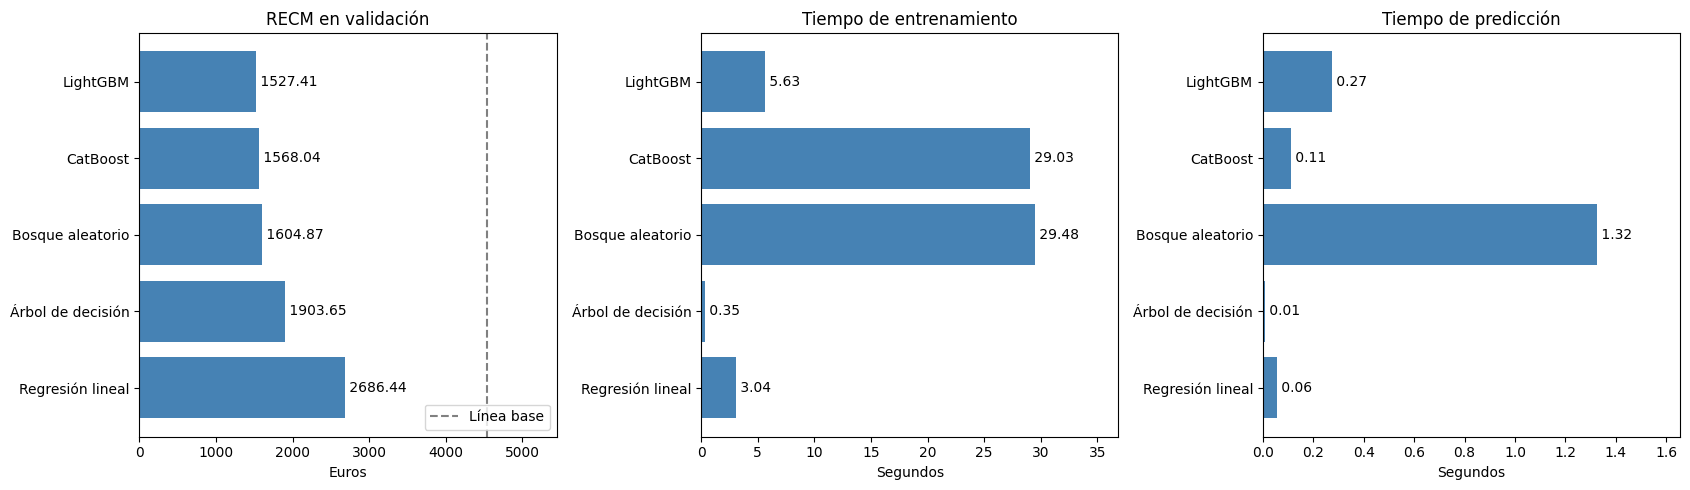

In [16]:
# ahora graficamos calidad y velocidad de la mejor versión de cada modelo
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
columnas_grafico = ['recm', 'entrenamiento_s', 'prediccion_s']
titulos = ['RECM en validación', 'Tiempo de entrenamiento', 'Tiempo de predicción']
etiquetas_x = ['Euros', 'Segundos', 'Segundos']

for i, columna in enumerate(columnas_grafico):
    ax = axes[i]
    ax.barh(mejores['modelo'], mejores[columna], color='steelblue')
    ax.invert_yaxis()
    ax.set_title(titulos[i])
    ax.set_xlabel(etiquetas_x[i])
    for j, valor in enumerate(mejores[columna]):
        ax.text(valor, j, ' ' + str(round(valor, 2)), va='center')
    ax.set_xlim(0, mejores[columna].max() * 1.25)

# en el primer gráfico marcamos la línea base para tener una referencia
axes[0].axvline(recm_base, color='gray', linestyle='--', label='Línea base')
axes[0].set_xlim(0, recm_base * 1.2)
axes[0].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Conclusión:** en calidad el orden es LightGBM (1527.41), CatBoost (1568.04), bosque aleatorio (1604.87), árbol de decisión (1903.65) y regresión lineal (2686.44). Todos mejoran la línea base de 4543.72, y la potenciación del gradiente supera a la regresión lineal, así que la prueba de cordura sale bien.

En velocidad, el árbol de decisión es el más rápido, pero su error es casi 400 euros más alto que el de LightGBM. CatBoost predice más rápido que LightGBM (unos 0.1 contra unos 0.3 segundos para más de 65 mil coches), pero en los dos casos es menos de medio segundo, algo que un usuario de la app no notaría. En cambio, LightGBM entrena unas cinco veces más rápido que CatBoost y que el bosque aleatorio. Por eso elijo LightGBM con 127 hojas y tasa de aprendizaje 0.1: es el más preciso y, entre los modelos de ensamble, el que menos tarda en entrenar.

### 3.2 Prueba final del modelo elegido

**Objetivo:** evaluar una sola vez con el conjunto de prueba el modelo elegido, para confirmar que su RECM no depende de haberlo ajustado con el conjunto de validación.

In [17]:
# ahora vamos a entrenar el modelo elegido y evaluarlo una sola vez con el conjunto de prueba
modelo_final = LGBMRegressor(n_estimators=300, num_leaves=127, learning_rate=0.1,
                             random_state=12345, verbose=-1)

inicio = time.time()
modelo_final.fit(lgbm_train, target_train)
tiempo_entrenamiento = time.time() - inicio

inicio = time.time()
predicciones_test = modelo_final.predict(lgbm_test)
tiempo_prediccion = time.time() - inicio

# para comparar, la línea base en prueba también usa la media del entrenamiento
predicciones_base_test = np.full(len(target_test), target_train.mean())

print('RECM del modelo final en prueba:', round(recm(target_test, predicciones_test), 2))
print('RECM de la línea base en prueba:', round(recm(target_test, predicciones_base_test), 2))
print('Tiempo de entrenamiento:', round(tiempo_entrenamiento, 2), 's')
print('Tiempo de predicción para', len(features_test), 'vehículos:', round(tiempo_prediccion, 3), 's')

RECM del modelo final en prueba: 1553.57
RECM de la línea base en prueba: 4554.74
Tiempo de entrenamiento: 5.7 s
Tiempo de predicción para 65393 vehículos: 0.312 s


**Conclusión:** en el conjunto de prueba LightGBM tiene una RECM de 1553.57 euros, muy cerca de los 1527.41 de validación, así que el resultado no dependía de haber elegido los hiperparámetros con ese conjunto. La línea base en prueba es 4554.74, casi tres veces más. Entrenar el modelo tomó unos 6 segundos y predecir el precio de 65393 vehículos, menos de medio segundo.

## Conclusiones generales

- Preparé los datos quitando duplicados, columnas que no describen al vehículo y anuncios con precio o año imposibles. Con eso perdí el 7.7 % de las filas. Las potencias imposibles y los ausentes de texto los rellené en lugar de borrarlos, porque borrarlos habría costado más del 11 % y el 26 % de los datos.
- Probé cinco modelos con distintos hiperparámetros. Todos mejoran la línea base de 4543.72 euros, y la potenciación del gradiente queda muy por delante de la regresión lineal (2686.44), así que la prueba de cordura sale bien.
- LightGBM con 127 hojas y tasa de aprendizaje 0.1 fue el más preciso, con una RECM de 1527.41 en validación y 1553.57 en prueba. También fue el modelo de ensamble que menos tardó en entrenar, unos 6 segundos, y predice más de 65 mil precios en menos de medio segundo.
- CatBoost quedó segundo en calidad y predice más rápido, pero tarda unas cinco veces más en entrenar. El bosque aleatorio quedó por detrás de los dos y es el más lento al predecir.

Para Rusty Bargain recomiendo LightGBM, porque junta la mejor calidad con tiempos bajos de entrenamiento y de predicción. Aun así, un error típico de unos 1550 euros pesa bastante en los vehículo baratos, así que en la app el precio debería presentarse como una estimación.

# Lista de control

Escribe 'x' para verificar. Luego presiona Shift+Enter

- [x]  Jupyter Notebook está abierto
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en orden de ejecución
- [x]  Los datos han sido descargados y preparados
- [x]  Los modelos han sido entrenados
- [x]  Se realizó el análisis de velocidad y calidad de los modelos